# TP3 Recuperatorio Grupal

**Modalidad:** grupos de 4 a 5 integrantes.

**Entrega:** notebook completo y ejecutable + corpus en `csv` o `jsonl`.

**Principio de trabajo:** un modelo puede acelerar tareas, pero no reemplaza una buena pregunta, un corpus bien construido ni el criterio humano. En analisis textual sigue valiendo la regla `garbage in, garbage out`.

## Introducción: El sentido del Análisis Computacional de Textos

Antes de ejecutar la primera línea de código, es fundamental comprender qué estamos buscando cuando aplicamos técnicas de Procesamiento de Lenguaje Natural (PLN) en las humanidades digitales y las ciencias sociales computacionales. Los algoritmos no "leen" ni "comprenden" los textos, sino que rastrean y cuantifican patrones lingüísticos. Nuestro trabajo como investigadores no es cederle la interpretación a la máquina, sino usar la computadora como una lente de aumento para volver visibles patrones discursivos.

Para que este enfoque funcione, hay tres dimensiones teórico-prácticas que debemos tener en cuenta:

### 1. El diseño del corpus: "Comparar lo comparable"

El paso analítico más importante no ocurre en el código, sino en la selección del corpus. Si comparamos textos que son inherentemente distintos, por ejemplo una novela romántica contra un manual de física, el algoritmo simplemente nos confirmará lo obvio. El verdadero poder del análisis computacional emerge cuando trabajamos sobre grandes volúmenes de textos que, en principio, parecen idénticos, comparten el mismo género, tratan sobre el mismo tema, ocurren en la misma fecha, pero difieren en una dimensión sutil, como su posición ideológica o su encuadre periodístico. El algoritmo nos permite medir matemáticamente cómo dos discursos construyen mundos diferentes a partir del mismo suceso.

### 2. La trampa del "Garbage In, Garbage Out"

Los modelos de PLN son literales. Si el corpus ingresa sucio, los resultados serán ruido. Un texto natural está lleno de "palabras vacías" (artículos, preposiciones) y verbos genéricos (ser, estar, hacer) que estadísticamente aplastan al vocabulario significativo. Del mismo modo, géneros como el periodismo incluyen vocabulario muy general del género ("nota", "gobierno", "ley") que no aporta valor analítico. El preprocesamiento de los datos, la eliminación de stopwords, la corrección de lemas, la limpieza de ruido estructural, no es una tarea técnica o automática; es una intervención interpretativa y humana crítica sin la cual el análisis resulta inútil.

### 3. Distinción algorítmica: De la frecuencia absoluta a la especificidad (TF-IDF)

Contar qué palabras se repiten más a menudo (frecuencia bruta) rara vez es revelador en grandes volúmenes de texto. La clave del análisis a escala está en encontrar el vocabulario distintivo. Técnicas estadísticas como el TF-IDF penalizan las palabras que todos usan por igual y exaltan aquellas que son exclusivas de un corpus frente a otro. Junto con el análisis de bigramas, pares de palabras que capturan locuciones o conceptos completos, estas métricas no reemplazan la lectura cualitativa: la potencian. Nos indican dónde mirar y qué palabras están funcionando como anclas ideológicas, para que luego nosotros, mediante una lectura atenta, podamos explicar el por qué.

## Que tienen que entregar

- este notebook completo y ejecutable;
- un corpus con **12 textos**: **6 por medio**;
- un mismo tema en ambos medios;
- la columna `grupo_comparacion` con exactamente dos valores posibles;
- una comparacion entre stopwords de `spaCy` y `NLTK`;
- al menos **dos ajustes humanos** del pipeline: uno lexico y uno estructural;
- una comparacion entre `Bag of Words` y `TF-IDF`;
- una lectura de bigramas;
- al menos dos visualizaciones analiticas legibles;
- una vuelta a fragmentos concretos del corpus;
- una conclusion interpretativa y metodologica.

## Que es un corpus

Un corpus no es una pila de textos. Un corpus es una coleccion **finita, explicita, comparable y documentada** de textos seleccionados para responder una pregunta.

Para este trabajo importa especialmente que el corpus:

- responda a una pregunta clara;
- use un criterio de inclusion visible;
- permita una comparacion defendible entre dos grupos;
- conserve trazabilidad de origen;
- haga visibles sus limites.

## Columnas minimas del corpus

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `url`
- `texto`
- `grupo_comparacion`

En la mayoria de los casos `grupo_comparacion` va a coincidir con los nombres de los dos medios elegidos.

In [1]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Elegimos un estilo simple y legible para todos los graficos.
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

# Ampliamos el ancho visible de las columnas textuales.
pd.set_option("display.max_colwidth", 160)

print("Entorno cargado.")

Entorno cargado.


## 0. Configuracion

Guarden el corpus en la misma carpeta que este notebook. Si usan otro nombre o formato, cambien las variables de esta celda.

In [ ]:
RUTA_CORPUS = Path("corpus_tp3.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_md"
TOP_N = 12
VENTANA_FRAGMENTO = 160

COLORES_GRUPO = {
    "infobae":  "#e63946",
    "lanacion": "#1d3557",
}

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Modelo spaCy esperado: {MODELO_SPACY}")

Ruta esperada del corpus: corpus_tp3.csv
Modelo spaCy esperado: es_core_news_md


## 1. Decisiones metodologicas

Agreguen una celda Markdown nueva y respondan, de manera breve, estas cuatro preguntas:

1. Que comparan exactamente.
2. Por que eligieron estos 12 textos y no otros.
3. Que vuelve comparables a ambos medios.
4. Que sesgos o limites iniciales ven en el corpus.

### Respuesta metodologica

En este trabajo se comparó noticias sobre inflacion publicadas por **Infobae** y **La Nacion**. El objetivo no es decir que un medio tiene razon y el otro no, sino observar que palabras, entidades y temas aparecen con mas fuerza en cada grupo.

Se eligieron esos 12 textos porque la consigna pide un corpus chico y balanceado: 6 notas de cada medio. Todas las notas tratan sobre inflacion, precios, IPC, mediciones oficiales o expectativas economicas durante los primeros meses de 2026. Eso permite comparar discursos bastante cercanos entre si.

Los dos medios son comparables porque pertenecen al mismo genero textual, la noticia periodistica economica, hablan del mismo problema publico y usan fuentes parecidas, como el INDEC, consultoras, economistas y funcionarios.

Como limite inicial, el corpus sigue siendo chico. Ademas, aunque la cantidad de textos esta balanceada, La Nacion tiene mas palabras totales que Infobae. Tambien puede haber sesgos por la seleccion de notas, por las fechas elegidas y por el hecho de trabajar solo con dos medios.


## 2. Carga y validacion del corpus

Vamos a trabajar en pasos separados. La idea es que se vea con claridad que valida cada bloque.

In [3]:
COLUMNAS_REQUERIDAS = [
    "id",
    "fecha",
    "medio",
    "autor",
    "titulo",
    "url",
    COLUMNA_TEXTO,
    COLUMNA_GRUPO,
]

# Primero revisamos si el archivo existe.
archivo_existe = RUTA_CORPUS.exists()

if not archivo_existe:
    raise FileNotFoundError(
        f"No se encontro {RUTA_CORPUS}. Guardalo en esta carpeta o corregi RUTA_CORPUS."
    )

# Despues revisamos si el formato declarado es valido.
formatos_validos = ["csv", "jsonl"]

if FORMATO_CORPUS not in formatos_validos:
    raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")

print("Archivo encontrado y formato declarado correctamente.")

Archivo encontrado y formato declarado correctamente.


In [4]:
# Esta celda solo carga el archivo. Todavia no valida su contenido.
if FORMATO_CORPUS == "csv":
    df = pd.read_csv(RUTA_CORPUS)
else:
    df = pd.read_json(RUTA_CORPUS, lines=True)

print(f"Archivo cargado: {len(df)} filas.")

Archivo cargado: 12 filas.


In [5]:
# Miramos una muestra del corpus tal como llego del archivo.
display(df.head())

,id,fecha,medio,autor,titulo,url,texto,grupo_comparacion
0,infobae_01,2026-02-10,Infobae,Lucrecia Eterovich,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses",https://www.infobae.com/economia/2026/02/10/la-inflacion-de-enero-fue-de-29-y-acumulo-324-en-los-ultimos-doce-meses/,"La inflación en enero de 2026 alcanzó 2,9%, según el Instituto Nacional de Estadística y Censos (Indec), lo que implicó una variación interanual de 32,4 por...",infobae
1,infobae_02,2026-03-12,Infobae,Lucrecia Eterovich,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses",https://www.infobae.com/economia/2026/03/12/la-inflacion-fue-de-29-en-febrero-y-acumulo-331-en-los-ultimos-doce-meses/,"La inflación de febrero alcanzó el 2,9%, según informó el Instituto Nacional de Estadística y Censos (Indec), misma cifra que en enero. En los últimos doce ...",infobae
2,infobae_03,2026-03-09,Infobae,Lucrecia Eterovich,"Inflación: Caputo espera un alivio en el dato de febrero, pero detectan aceleración en marzo",https://www.infobae.com/economia/2026/03/09/inflacion-caputo-espera-un-alivio-en-el-dato-de-febrero-pero-detectan-aceleracion-en-marzo/,"Luego del 2,9% que marcó la inflación en enero, hilvanando cinco meses de aceleración mensual, el Gobierno espera que el dato de febrero sea algo inferior y...",infobae
3,infobae_04,2026-02-18,Infobae,Martín Fernández Nadale,La desinflación se hace esperar: por qué la suba de precios no cede y qué pasará en febrero,https://www.infobae.com/economia/2026/02/18/la-desinflacion-se-hace-esperar-por-que-la-suba-de-precios-no-cede-y-que-pasara-en-febrero/,"El sendero de desinflación se interrumpió a mediados de 2025 y, desde entonces, la suba generalizada de los precios de la economía argentina experimentó una...",infobae
4,infobae_05,2026-03-02,Infobae,Redaccion,Caputo aseguró que la inflación mensual puede empezar con 0 este año y que el cepo está “90% levantado”,https://www.infobae.com/economia/2026/03/02/caputo-aseguro-que-la-inflacion-mensual-puede-empezar-con-0-este-ano-y-que-el-cepo-esta-90-levantado/,"El ministro de Economía, Luis Caputo, aseguró que la inflación de febrero será menor al número de enero, a la vez que sostuvo que este año el índice mensual...",infobae


In [6]:
# Ahora revisamos si estan todas las columnas obligatorias.
faltantes = []

for columna in COLUMNAS_REQUERIDAS:
    if columna not in df.columns:
        faltantes.append(columna)

if faltantes:
    mensaje = ", ".join(faltantes)
    raise ValueError("Faltan columnas obligatorias: " + mensaje)

print("Columnas obligatorias presentes.")

Columnas obligatorias presentes.


In [7]:
# Revisamos la cantidad total de textos.
cantidad_textos = len(df)

if cantidad_textos != 12:
    raise ValueError("El corpus debe tener exactamente 12 textos.")

print("Cantidad total de textos correcta: 12.")

Cantidad total de textos correcta: 12.


In [8]:
# Limpiamos la columna de grupos antes de contar.
# 'fillna' reemplaza valores vacios.
# 'astype(str)' convierte la columna a texto.
# 'str.strip()' quita espacios al principio y al final.
grupos_limpios = df[COLUMNA_GRUPO]
grupos_limpios = grupos_limpios.fillna("")
grupos_limpios = grupos_limpios.astype(str)
grupos_limpios = grupos_limpios.str.strip()

df[COLUMNA_GRUPO] = grupos_limpios

print("Columna de grupos limpiada.")

Columna de grupos limpiada.


In [9]:
# 'value_counts' cuenta cuantas veces aparece cada valor.
conteos_grupo = df[COLUMNA_GRUPO].value_counts()

grupos_unicos = []
for grupo in conteos_grupo.index.tolist():
    if grupo != "":
        grupos_unicos.append(grupo)

if len(grupos_unicos) != 2:
    raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")

conteos_ordenados = sorted(conteos_grupo.tolist())

if conteos_ordenados != [6, 6]:
    raise ValueError("Cada grupo debe tener exactamente 6 textos.")

print("Cantidad de grupos correcta.")
print("Textos por grupo:")
display(conteos_grupo)

Cantidad de grupos correcta.
Textos por grupo:


grupo_comparacion
infobae     6
lanacion    6
Name: count, dtype: int64

In [10]:
# Normalizamos algunas columnas para evitar problemas de espacios o valores vacios.
columnas_textuales = ["id", "medio", "autor", "titulo", "url", COLUMNA_TEXTO, COLUMNA_GRUPO]

for columna in columnas_textuales:
    df[columna] = df[columna].fillna("")
    df[columna] = df[columna].astype(str)
    df[columna] = df[columna].str.strip()

# Convertimos la fecha a un formato temporal estandar.
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

print("Columnas normalizadas.")

Columnas normalizadas.


In [11]:
# Este patron busca secuencias de letras de largo 2 o mas.
# Nos sirve para una cuenta aproximada de palabras.
patron_palabras = r"\b[^\W\d_]{2,}\b"

coincidencias_por_texto = df[COLUMNA_TEXTO].str.findall(patron_palabras)
cantidades_palabras = coincidencias_por_texto.str.len()

df["num_palabras"] = cantidades_palabras

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:")
display(pd.Series(grupos_unicos))

columnas_mostrar = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]
display(df[columnas_mostrar])

Documentos cargados: 12
Grupos detectados:


0     infobae
1    lanacion
dtype: str

,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,infobae_01,2026-02-10,Infobae,Lucrecia Eterovich,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses",infobae,646
1,infobae_02,2026-03-12,Infobae,Lucrecia Eterovich,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses",infobae,977
2,infobae_03,2026-03-09,Infobae,Lucrecia Eterovich,"Inflación: Caputo espera un alivio en el dato de febrero, pero detectan aceleración en marzo",infobae,873
3,infobae_04,2026-02-18,Infobae,Martín Fernández Nadale,La desinflación se hace esperar: por qué la suba de precios no cede y qué pasará en febrero,infobae,1245
4,infobae_05,2026-03-02,Infobae,Redaccion,Caputo aseguró que la inflación mensual puede empezar con 0 este año y que el cepo está “90% levantado”,infobae,810
5,infobae_06,2026-05-01,Infobae,Pablo Wende,Abril cerró con inflación en baja por primera vez en diez meses: ¿en mayo se puede perforar el 2%?,infobae,577
6,lanacion_01,2026-02-10,LaNacion,Francisco Jueguen,"En medio de la polémica por la medición de la inflación, el IPC de enero marcó un 2,9%",lanacion,1312
7,lanacion_02,2026-02-27,LaNacion,María Julieta Rumi,La inflación de febrero sería similar a la de enero y recién cedería en abril,lanacion,607
8,lanacion_03,2026-03-12,LaNacion,Agustín Maza,"La inflación de febrero fue 2,9%, por encima de lo esperado por el mercado",lanacion,1096
9,lanacion_04,2026-03-13,LaNacion,Redaccion,Caputo habló sobre el dato de inflación de febrero y dijo que podría perforar el 1% mensual en 2026,lanacion,678


## 3. Auditoria del corpus

Antes de interpretar, conviene hacer una auditoria basica del recorte. En un corpus chico, los desbalances importan mucho.

In [12]:
# Armamos una tabla breve con metricas generales del corpus.
metricas = ["documentos", "palabras aproximadas", "promedio por texto"]
valores = []

valores.append(len(df))
valores.append(int(df["num_palabras"].sum()))
valores.append(round(float(df["num_palabras"].mean()), 1))

resumen_corpus = pd.DataFrame({"metrica": metricas, "valor": valores})
display(resumen_corpus)

,metrica,valor
0,documentos,12.0
1,palabras aproximadas,11161.0
2,promedio por texto,930.1


In [13]:
# 'groupby' agrupa filas segun una columna.
# En este caso agrupamos por medio para comparar las dos series.
agrupado = df.groupby(COLUMNA_GRUPO)

# 'agg' sirve para resumir cada grupo con una o varias operaciones.
resumen_por_grupo = agrupado.agg(
    documentos=("id", "count"),
    palabras_totales=("num_palabras", "sum"),
    promedio_palabras=("num_palabras", "mean"),
)

# 'reset_index' devuelve el indice a una columna comun.
resumen_por_grupo = resumen_por_grupo.reset_index()

# 'sort_values' ordena las filas.
resumen_por_grupo = resumen_por_grupo.sort_values(COLUMNA_GRUPO)

display(resumen_por_grupo.round(1))

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,infobae,6,5128,854.7
1,lanacion,6,6033,1005.5


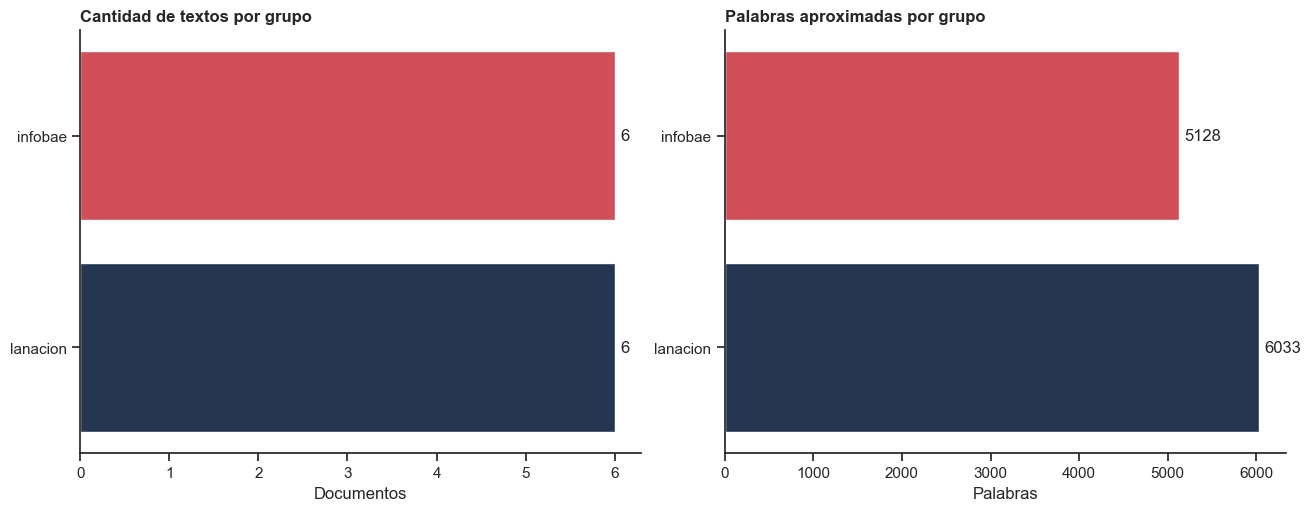

In [83]:
# Grafico 1: cantidad de textos por grupo.
# Grafico 2: cantidad aproximada de palabras por grupo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette=COLORES_GRUPO,
    legend=False,
    ax=axes[0],
)

axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")

for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor, fmt="%.0f", padding=4)

sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette=COLORES_GRUPO,
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")

for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor, fmt="%.0f", padding=4)

sns.despine()
plt.show()

Agreguen una celda Markdown nueva y anoten si ven desbalances de longitud, autoria, fechas o recorte.

### Auditoria del corpus

El corpus cumple con la cantidad pedida de **12 textos**, divididos en **6 de Infobae** y **6 de La Nacion**. En ese sentido, esta balanceado por cantidad de articulos.

Sin embargo, no esta perfectamente balanceado por longitud. Infobae tiene aproximadamente **5100 palabras**, mientras que La Nacion tiene aproximadamente **6000 palabras**. La diferencia no es extrema, pero puede hacer que algunos terminos aparezcan mas en La Nacion simplemente porque hay mas texto.

En la autoría se ve algo de variedad, ya que varias notas tienen autores identificados. Sin embargo, todavía aparecen algunos casos como `Redaccion`, que se usan cuando la nota no informa un autor individual o cuando el scraping no puede detectarlo. En fechas, el recorte va de febrero a mayo de 2026 en Infobae y de febrero a abril de 2026 en La Nacion.


## 4. Inspeccion con spaCy (`es_core_news_md`)

En esta parte no basta con ejecutar. Miren como el modelo tokeniza, lematiza, etiqueta y reconoce entidades en su corpus.

**Vocabulario de esta seccion**

- **pipeline**: secuencia de operaciones que el modelo aplica al texto;
- **token**: unidad de texto separada por el modelo;
- **lema**: forma base de una palabra;
- **POS**: categoria gramatical general;
- **dependencia**: relacion sintactica entre palabras;
- **entidad**: nombre propio, organizacion, lugar u otra expresion relevante;
- **rasgo morfologico**: informacion como numero, genero o persona.

In [15]:
try:
    import spacy
    from spacy.matcher import Matcher
    nlp = spacy.load(MODELO_SPACY)
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalen el modelo con: python -m spacy download es_core_news_md"
    ) from error

# Ajustamos algunas stopwords que pueden resultar utiles en corpus en espanol.
nlp.vocab["él"].is_stop = True
nlp.vocab["ella"].is_stop = True

print(f"Modelo cargado: {MODELO_SPACY}")
print("Pipeline activo:")
display(pd.Series(nlp.pipe_names))

Modelo cargado: es_core_news_md
Pipeline activo:


0            tok2vec
1      morphologizer
2             parser
3    attribute_ruler
4         lemmatizer
5                ner
dtype: str

In [16]:
# 'pipe' procesa muchos textos de una vez.
# Lo usamos porque todo el corpus pasa por el mismo pipeline.
textos_corpus = df[COLUMNA_TEXTO].tolist()
docs_base = list(nlp.pipe(textos_corpus))

print(f"Documentos procesados con spaCy: {len(docs_base)}")

Documentos procesados con spaCy: 12


In [17]:
def normalizar_lemma(token):
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower()

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-":
        lema = token.text.lower()

    return lema

texto_muestra = df.loc[0, COLUMNA_TEXTO]
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento):
    if indice >= 25:
        break

    if token.is_space:
        continue

    # 'pos_' es la categoria gramatical general.
    # 'tag_' es una etiqueta mas especifica.
    # 'dep_' muestra la relacion sintactica.
    # 'morph' guarda rasgos como numero, genero o persona.
    registro_token = {
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }
    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens)
display(tabla_tokens)

,token,lemma,pos,tag,dep,ent,morph
0,La,el,DET,DET,det,-,Definite=Def|Gender=Fem|Number=Sing|PronType=Art
1,inflación,inflación,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
2,en,en,ADP,ADP,case,-,-
3,enero,enero,NOUN,NOUN,nmod,-,-
4,de,de,ADP,ADP,case,-,-
5,2026,2026,NUM,NUM,compound,-,NumForm=Digit|NumType=Card
6,alcanzó,alcanzar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin
7,"2,9%","2,9%",SYM,SYM,obj,-,NumForm=Digit|NumType=Frac
8,",",",",PUNCT,PUNCT,punct,-,PunctType=Comm
9,según,según,ADP,ADP,case,-,-


In [18]:
# Esta funcion arma una tabla de frecuencias para una familia de etiquetas.
def tabla_etiquetas(docs, atributo, incluir_vacios=False):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            valor = getattr(token, atributo)

            if not valor and not incluir_vacios:
                continue

            if not valor:
                valor = "-"

            contador[valor] += 1

    filas = []

    for etiqueta, frecuencia in contador.most_common():
        descripcion = "-"

        if etiqueta != "-":
            explicacion = spacy.explain(etiqueta)
            if explicacion:
                descripcion = explicacion

        fila = {
            "etiqueta": etiqueta,
            "descripcion": descripcion,
            "frecuencia": frecuencia,
        }
        filas.append(fila)

    return pd.DataFrame(filas)

In [19]:
tabla_pos = tabla_etiquetas(docs_base, "pos_")

print("POS detectadas")
display(tabla_pos.head(15))

POS detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,2752
1,ADP,adposition,2163
2,DET,determiner,1839
3,PUNCT,punctuation,1791
4,VERB,verb,1201
5,ADJ,adjective,1011
6,PROPN,proper noun,696
7,PRON,pronoun,508
8,ADV,adverb,477
9,CCONJ,coordinating conjunction,388


In [20]:
tabla_tag = tabla_etiquetas(docs_base, "tag_")

print("TAG detectadas")
display(tabla_tag.head(15))

TAG detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,2752
1,ADP,adposition,2163
2,DET,determiner,1839
3,PUNCT,punctuation,1791
4,VERB,verb,1201
5,ADJ,adjective,1011
6,PROPN,proper noun,696
7,PRON,pronoun,508
8,ADV,adverb,477
9,CCONJ,coordinating conjunction,388


In [21]:
tabla_dep = tabla_etiquetas(docs_base, "dep_")

print("Dependencias detectadas")
display(tabla_dep.head(15))

Dependencias detectadas


d:\vega-sebastian-pdi-1c-2026\009\003-LAB\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pass' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
d:\vega-sebastian-pdi-1c-2026\009\003-LAB\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pv' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
d:\vega-sebastian-pdi-1c-2026\009\003-LAB\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:impers' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.war

,etiqueta,descripcion,frecuencia
0,case,case marking,1950
1,det,determiner,1876
2,punct,punctuation,1798
3,nmod,modifier of nominal,1003
4,nsubj,nominal subject,851
5,amod,adjectival modifier,844
6,obl,oblique nominal,685
7,obj,object,652
8,advmod,adverbial modifier,523
9,ROOT,root,482


In [22]:
tabla_ent = tabla_etiquetas(docs_base, "ent_type_")

print("Entidades detectadas")
display(tabla_ent.head(15))

Entidades detectadas


,etiqueta,descripcion,frecuencia
0,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",550
1,PER,Named person or family.,211
2,LOC,"Non-GPE locations, mountain ranges, bodies of water",189
3,ORG,"Companies, agencies, institutions, etc.",170


In [23]:
# Revision especifica de entidades MISC
# Importante: la tabla anterior cuenta tokens con ent_type_ = MISC.
# Para revisar "cuales son", conviene pasar a nivel de entidad completa usando doc.ents.

registros_entidades_base = []

for fila, doc in zip(df.itertuples(index=False), docs_base):
    for ent in doc.ents:
        registros_entidades_base.append({
            "id": fila.id,
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "medio": fila.medio,
            "titulo": fila.titulo,
            "entidad": ent.text,
            "label_original": ent.label_,
            "tokens_entidad": len(ent),
            "inicio": ent.start_char,
            "fin": ent.end_char,
        })

df_entidades_base = pd.DataFrame(registros_entidades_base)

misc_base = df_entidades_base[df_entidades_base["label_original"] == "MISC"].copy()

print("Tokens MISC contados en la tabla anterior:", int(misc_base["tokens_entidad"].sum()))
print("Spans MISC detectados:", len(misc_base))
print("Spans MISC unicos:", misc_base["entidad"].str.lower().nunique())

misc_frecuencias = (
    misc_base
    .assign(entidad_normalizada=misc_base["entidad"].str.strip().str.lower())
    .groupby(["entidad_normalizada"], as_index=False)
    .agg(
        entidad=("entidad", "first"),
        frecuencia=("entidad", "size"),
        tokens_sumados=("tokens_entidad", "sum"),
        grupos=("grupo", lambda x: ", ".join(sorted(set(x)))),
        ejemplos_id=("id", lambda x: ", ".join(list(dict.fromkeys(x))[:3])),
    )
    .sort_values(["frecuencia", "tokens_sumados"], ascending=False)
)

display(misc_frecuencias.head(80))


Tokens MISC contados en la tabla anterior: 550
Spans MISC detectados: 187
Spans MISC unicos: 146


,entidad_normalizada,entidad,frecuencia,tokens_sumados,grupos,ejemplos_id
6,analytica,Analytica,15,15,"infobae, lanacion","infobae_01, infobae_02, infobae_03"
105,medio oriente,Medio Oriente,5,10,"infobae, lanacion","infobae_02, infobae_05, infobae_06"
120,precios al consumidor,Precios al Consumidor,4,12,"infobae, lanacion","infobae_02, infobae_04, infobae_06"
56,encuesta nacional de gastos,Encuesta Nacional de Gastos,3,12,"infobae, lanacion","infobae_04, lanacion_03"
33,el gobierno,El Gobierno,3,6,"infobae, lanacion","infobae_01, infobae_02, lanacion_05"
...,...,...,...,...,...,...
38,el mismo trimestre,El mismo trimestre,1,3,lanacion,lanacion_05
39,el organismo local,El organismo local,1,3,infobae,infobae_01
42,el presidente milei,El presidente Milei,1,3,infobae,infobae_02
45,el registro porteño,El registro porteño,1,3,infobae,infobae_01


In [24]:
def fragmento_entidad(texto, inicio, fin, ventana=120):
    inicio_frag = max(0, inicio - ventana)
    fin_frag = min(len(texto), fin + ventana)
    frag = texto[inicio_frag:fin_frag].replace("\n", " ").strip()
    if inicio_frag > 0:
        frag = "..." + frag
    if fin_frag < len(texto):
        frag = frag + "..."
    return frag

# Muestra con contexto para decidir si una entidad MISC debe reclasificarse.
registros_contexto_misc = []

for fila_misc in misc_base.head(120).itertuples(index=False):
    texto_original = df.loc[df["id"] == fila_misc.id, COLUMNA_TEXTO].iloc[0]
    registros_contexto_misc.append({
        "id": fila_misc.id,
        "grupo": fila_misc.grupo,
        "entidad": fila_misc.entidad,
        "label_original": fila_misc.label_original,
        "fragmento": fragmento_entidad(texto_original, fila_misc.inicio, fila_misc.fin, ventana=VENTANA_FRAGMENTO),
    })

df_contexto_misc = pd.DataFrame(registros_contexto_misc)
display(df_contexto_misc)


,id,grupo,entidad,label_original,fragmento
0,infobae_01,infobae,El dato,MISC,"...flación en enero de 2026 alcanzó 2,9%, según el Instituto Nacional de Estadística y Censos (Indec), lo que implicó una variación interanual de 32,4 por c..."
1,infobae_01,infobae,Verduras,MISC,"...onal, Alimentos y bebidas no alcohólicas tuvo el mayor impacto en la variación mensual, impulsado sobre todo por incrementos en Carnes y derivados, así c..."
2,infobae_01,infobae,Por el contrario,MISC,"...ólicas tuvo el mayor impacto en la variación mensual, impulsado sobre todo por incrementos en Carnes y derivados, así como en Verduras, tubérculos y legu..."
3,infobae_01,infobae,Educación,MISC,"...sobre todo por incrementos en Carnes y derivados, así como en Verduras, tubérculos y legumbres. Por el contrario, las menores subas en el mes correspondi..."
4,infobae_01,infobae,La semana pasada,MISC,"...un 5,7%, seguidos por el IPC núcleo (2,6%) y los precios Regulados (2,4%). En efecto, el dato se difundió en medio de un debate sobre la metodología del ..."
...,...,...,...,...,...
115,lanacion_03,lanacion,De esta manera,MISC,"...ismo período de 2025 (4,7%). El dato también implica que la inflación no logró desacelerarse respecto de enero, cuando había marcado el mismo registro me..."
116,lanacion_03,lanacion,Tras,MISC,"...o había marcado el mismo registro mensual. De esta manera, el indicador consolidó una dinámica que en los últimos meses había mostrado una aceleración gr..."
117,lanacion_03,lanacion,El rubro Vivienda,MISC,"...los datos oficiales. El informe del Indec mostró que una de las principales presiones del mes provino de los servicios regulados, en particular de las ta..."
118,lanacion_03,lanacion,El ministro,MISC,"...dor se mantiene dentro de un proceso de corrección de precios relativos que, según el Gobierno, busca ordenar la economía tras años de distorsiones acumu..."


In [25]:
# Reclasificacion

RECLASIFICACION_MISC = {
    # Organismos, consultoras e instituciones economicas
    "indec": "ORG",
    "instituto nacional de estadística y censos": "ORG",
    "instituto nacional de estadistica y censos": "ORG",
    "banco central": "ORG",
    "bcra": "ORG",
    "ministerio de economía": "ORG",
    "ministerio de economia": "ORG",
    "fmi": "ORG",
    "fondo monetario internacional": "ORG",
    "fundación libertad y progreso": "ORG",
    "fundacion libertad y progreso": "ORG",
    "eco go": "ORG",
    "lcg": "ORG",
    "econviews": "ORG",
    "equilibra": "ORG",
    "analytica": "ORG",
    "invecq": "ORG",
    "asesores económicos": "ORG",
    "asesores economicos": "ORG",
    "ate indec": "ORG",
    "dirección general de estadística y censos": "ORG",
    "direccion general de estadistica y censos": "ORG",
    "la sociedad argentina de estadística": "ORG",
    "jp morgan": "ORG",
    "afa": "ORG",
    "ypf":"ORG",

    # Personas
    "luis caputo": "PER",
    "caputo": "PER",
    "javier milei": "PER",
    "milei": "PER",
    "marco lavagna": "PER",
    "lavagna": "PER",
    "florencia iragui": "PER",
    "lorenzo sigaut gravina": "PER",
    "sigaut gravina": "PER",
    "miguel kiguel": "PER",
    "iván cachanosky": "PER",
    "ivan cachanosky": "PER",
    "cachanosky": "PER",
    "camilo tiscornia": "PER",
    "claudio caprarulo": "PER",
    "ricardo delgado": "PER",
    "adorni": "PER",
    "manuel adorni": "PER",
    "maecela pagano": "PER",
    "sebastián menescaldi": "PER",
    "santiago bausili": "PER",
    "luis cubeddu": "PER",
    "lucio garay méndez": "PER",
    "julián neufeld": "PER",
    "jorge todesca": "PER",
    "guillermo moreno": "PER",
    "cristina kirchner":"PER",
    "graciela bevacqua": "PER",
    "alejandro giacoia": "PER",
    "donald trump":"PER",
    "bettina angeletti": "PER",
    "carlos quintriqueo":"PER",

    # Lugares
    "argentina": "LOC",
    "república argentina": "LOC",
    "republica argentina": "LOC",
    "caba": "LOC",
    "ciudad autónoma de buenos aires": "LOC",
    "ciudad autonoma de buenos aires": "LOC",
    "ciudad": "LOC",
    "gran buenos aires": "LOC",
    "medio oriente": "LOC",
    "rosario": "LOC",
    "ciudad de Buenos Aires": "LOC",
    "amba": "LOC",
    "nueva york": "LOC",
    "uruguay":"LOC",

    # Indicadores, indices, relevamientos o instrumentos: aca MISC puede estar ok.
    "ipc": "MISC",
    "índice de precios al consumidor": "MISC",
    "indice de precios al consumidor": "MISC",
    "rem": "MISC",
    "relevamiento de expectativas de mercado": "MISC",
    "relevamiento de expectativas del mercado": "MISC",
    "engho": "MISC",
    "encuesta nacional de gastos de los hogares": "MISC",
}

def normalizar_entidad_texto(texto):
    return " ".join(str(texto).strip().lower().split())

def label_reclasificado(entidad, label_original):
    clave = normalizar_entidad_texto(entidad)
    return RECLASIFICACION_MISC.get(clave, label_original)

if not df_entidades_base.empty:
    df_entidades_revisadas = df_entidades_base.copy()
    df_entidades_revisadas["label_revisado"] = df_entidades_revisadas.apply(
        lambda fila: label_reclasificado(fila["entidad"], fila["label_original"]),
        axis=1,
    )

    cambios_entidades = df_entidades_revisadas[
        df_entidades_revisadas["label_original"] != df_entidades_revisadas["label_revisado"]
    ].copy()

    print("Entidades reclasificadas:", len(cambios_entidades))
    display(
        cambios_entidades[["id", "grupo", "entidad", "label_original", "label_revisado"]]
        .drop_duplicates()
        .sort_values(["label_revisado", "entidad"])
        .head(120)
    )

    print("Resumen antes/despues")
    resumen_reclasificacion = pd.concat(
        [
            df_entidades_revisadas["label_original"].value_counts().rename("antes"),
            df_entidades_revisadas["label_revisado"].value_counts().rename("despues"),
        ],
        axis=1,
    ).fillna(0).astype(int)
    display(resumen_reclasificacion)


Entidades reclasificadas: 70


,id,grupo,entidad,label_original,label_revisado
102,infobae_02,infobae,Medio Oriente,MISC,LOC
189,infobae_05,infobae,Medio Oriente,MISC,LOC
213,infobae_06,infobae,Medio Oriente,MISC,LOC
442,lanacion_05,lanacion,Medio Oriente,MISC,LOC
154,infobae_04,infobae,ENGHo,LOC,MISC
336,lanacion_03,lanacion,ENGHo,LOC,MISC
34,infobae_01,infobae,Analytica,MISC,ORG
64,infobae_02,infobae,Analytica,MISC,ORG
116,infobae_03,infobae,Analytica,MISC,ORG
169,infobae_04,infobae,Analytica,MISC,ORG


Resumen antes/despues


,antes,despues
MISC,187,167
LOC,140,102
PER,129,127
ORG,91,151


In [26]:
def tabla_morph(docs):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            rasgos = str(token.morph)

            if not rasgos:
                rasgos = "-"

            contador[rasgos] += 1

    filas = []

    for rasgos, frecuencia in contador.most_common():
        filas.append({"morph": rasgos, "frecuencia": frecuencia})

    return pd.DataFrame(filas)

tabla_morf = tabla_morph(docs_base)

print("Rasgos morfologicos detectados")
display(tabla_morf.head(15))

Rasgos morfologicos detectados


,morph,frecuencia
0,-,3845
1,Gender=Masc|Number=Sing,973
2,Gender=Fem|Number=Sing,896
3,PunctType=Comm,830
4,Definite=Def|Gender=Masc|Number=Sing|PronType=Art,814
5,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,497
6,Gender=Masc|Number=Plur,483
7,PunctType=Peri,481
8,Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin,412
9,Number=Sing,289


Agreguen una celda Markdown nueva y registren al menos **dos limites o errores** que observen en el pipeline de `spaCy` sobre su corpus.

### Limites observados en spaCy

Un primer limite fue la clasificacion de entidades. La salida inicial mostraba muchos casos `MISC`, pero al mirar con mas detalle vimos que ahi estaban mezcladas cosas muy distintas: organismos, consultoras, lugares, indices economicos y tambien frases que no son entidades claras. Por eso fue necesario revisar `doc.ents` y no quedarse solo con la tabla de frecuencias.

Un segundo limite fue que algunas entidades economicas aparecian con etiquetas discutibles. Por ejemplo, `Banco Central` o consultoras como `Analytica`, `Eco Go` y `Econviews` podian aparecer como `LOC`, `PER` o `MISC`, cuando para este corpus tiene mas sentido tratarlas como `ORG`.

Tambien vi que algunas expresiones completas, como `Indice de Precios al Consumidor` o `Relevamiento de Expectativas de Mercado`, son importantes para el tema pero no siempre quedan bien tomadas como unidad. Por eso agregamos reglas con `Matcher` y `EntityRuler`.


## 5. Stopwords: `spaCy` vs `NLTK`

Comparen ambos enfoques antes de decidir. No existe una lista universalmente correcta.

**Vocabulario de esta seccion**

- **stopword**: palabra muy frecuente que muchas veces aporta poco para diferenciar textos;
- **lista base**: conjunto inicial de stopwords que tomamos de una libreria;
- **lista ajustada**: lista base modificada segun las necesidades del corpus.

In [27]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stopwords_nltk = set(stopwords.words("spanish"))
stopwords_nltk.add("él")

stopwords_spacy = set(nlp.Defaults.stop_words)
stopwords_spacy.add("él")

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

Stopwords spaCy: 521
Stopwords NLTK: 313


In [28]:
# Comparamos algunas diferencias entre listas.
solo_spacy = stopwords_spacy - stopwords_nltk
solo_nltk = stopwords_nltk - stopwords_spacy

lista_solo_spacy = list(solo_spacy)
lista_solo_spacy = sorted(lista_solo_spacy)
muestra_solo_spacy = lista_solo_spacy[:20]

lista_solo_nltk = list(solo_nltk)
lista_solo_nltk = sorted(lista_solo_nltk)
muestra_solo_nltk = lista_solo_nltk[:20]

print("Ejemplos de palabras que aparecen solo en spaCy:")
display(pd.Series(muestra_solo_spacy))

print("Ejemplos de palabras que aparecen solo en NLTK:")
display(pd.Series(muestra_solo_nltk))

Ejemplos de palabras que aparecen solo en spaCy:


0             acuerdo
1            adelante
2              ademas
3              además
4              afirmó
5              agregó
6                 ahi
7               ahora
8                 ahí
9              alguna
10             alguno
11              algún
12               alli
13               allí
14          alrededor
15              ambos
16           anterior
17             apenas
18    aproximadamente
19              aquel
dtype: str

Ejemplos de palabras que aparecen solo en NLTK:


0          erais
1       estabais
2        estabas
3          estad
4         estada
5        estadas
6        estando
7      estaremos
8        estarán
9        estarás
10        estaré
11      estaréis
12       estaría
13     estaríais
14    estaríamos
15      estarían
16      estarías
17       estemos
18        estuve
19     estuviera
dtype: str

In [29]:
def texto_contenido_desde_doc(doc, stopwords_base):
    # Esta funcion arma una version reducida del texto.
    # Conserva solo palabras alfabeticas que no sean stopwords.
    tokens = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = normalizar_lemma(token)

        if forma in stopwords_base:
            continue

        if lema in stopwords_base:
            continue

        tokens.append(lema)

    texto_limpio = " ".join(tokens)
    return texto_limpio

In [30]:
textos_spacy_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_spacy)
    textos_spacy_stop.append(texto_limpio)

df["texto_spacy_stop"] = textos_spacy_stop

display(df[["titulo", "texto_spacy_stop"]].head())

,titulo,texto_spacy_stop
0,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses",inflación enero alcanzar instituto nacional estadística censos indec implicar variación interanual ciento dato publicar cuestionamiento salida marco lavagna...
1,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses",inflación febrero alcanzar instituto nacional estadística censos indec cifra enero mes subir acumulado bimestre año sumar ciento presidente javier milei pre...
2,"Inflación: Caputo espera un alivio en el dato de febrero, pero detectan aceleración en marzo",marcar inflación enero hilvanar mes aceleración mensual gobierno esperar dato febrero inferior permita aliviar bolsillo expectativa relevamiento consultora ...
3,La desinflación se hace esperar: por qué la suba de precios no cede y qué pasará en febrero,sendero desinflación interrumpir mediados subir generalizado precio economía argentino experimentar aceleración cuyo punto alto tocar enero año principal an...
4,Caputo aseguró que la inflación mensual puede empezar con 0 este año y que el cepo está “90% levantado”,ministro economía luis caputo inflación febrero menor número enero sostener año índice mensual empezar mantener rumbo fiscal monetario mantener curso tranqu...


In [31]:
textos_nltk_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_nltk)
    textos_nltk_stop.append(texto_limpio)

df["texto_nltk_stop"] = textos_nltk_stop

display(df[["titulo", "texto_nltk_stop"]].head())

,titulo,texto_nltk_stop
0,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses",inflación enero alcanzar según instituto nacional estadística censos indec implicar variación interanual ciento dato publicar medio cuestionamiento tras sal...
1,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses",inflación febrero alcanzar según informar instituto nacional estadística censos indec mismo cifra enero último doce mes subir acumulado mientras primero bim...
2,"Inflación: Caputo espera un alivio en el dato de febrero, pero detectan aceleración en marzo",luego marcar inflación enero hilvanar cinco mes aceleración mensual gobierno esperar dato febrero inferior permita aliviar bolsillo expectativa relevamiento...
3,La desinflación se hace esperar: por qué la suba de precios no cede y qué pasará en febrero,sendero desinflación interrumpir mediados entonces subir generalizado precio economía argentino experimentar aceleración cuyo punto alto tocar enero año si ...
4,Caputo aseguró que la inflación mensual puede empezar con 0 este año y que el cepo está “90% levantado”,ministro economía luis caputo asegurar inflación febrero menor número enero vez sostener año índice mensual poder empezar si mantener rumbo fiscal monetario...


In [32]:
def obtener_top_terminos_por_grupo(dataframe, columna_texto, top_n=10):
    # Esta funcion cuenta los terminos mas frecuentes dentro de cada grupo.
    filas = []

    grupos = dataframe.groupby(COLUMNA_GRUPO)

    for grupo, subconjunto in grupos:
        texto_total = " ".join(subconjunto[columna_texto])
        lista_terminos = texto_total.split()
        contador = Counter(lista_terminos)

        # 'most_common' devuelve pares (termino, frecuencia)
        # ordenados de mayor a menor.
        top = contador.most_common(top_n)

        for termino, frecuencia in top:
            fila = {
                "grupo": grupo,
                "termino": termino,
                "frecuencia": frecuencia,
            }
            filas.append(fila)

    tabla_top = pd.DataFrame(filas)
    return tabla_top

In [33]:
top_spacy_stop = obtener_top_terminos_por_grupo(df, "texto_spacy_stop", top_n=TOP_N)

print("Top con stopwords de spaCy")
display(top_spacy_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
0,infobae,inflación,48
1,infobae,mes,42
2,infobae,precio,37
3,infobae,semana,30
4,infobae,aumento,22
5,infobae,marzo,22
6,infobae,año,22
7,infobae,enero,20
8,infobae,mercado,20
9,infobae,bebida,19


In [34]:
top_nltk_stop = obtener_top_terminos_por_grupo(df, "texto_nltk_stop", top_n=TOP_N)

print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de NLTK


,grupo,termino,frecuencia
0,infobae,inflación,48
1,infobae,mes,42
2,infobae,precio,37
3,infobae,semana,30
4,infobae,aumento,22
5,infobae,marzo,22
6,infobae,año,22
7,infobae,enero,20
8,infobae,mercado,20
9,infobae,primero,20


Agreguen una celda Markdown nueva y respondan: **que lista sirve mejor para este corpus y por que**.

### Comparacion de stopwords

Para este corpus sirve mejor partir de la lista de **spaCy**, porque es mas amplia que la de NLTK (500 vs 300 aprox.). spaCy trae mas palabras funcionales y tambien algunas formas verbales frecuentes que, en noticias, suelen aportar poco para diferenciar el contenido.

De todos modos, no usamos la lista de forma automatica. Hicimos un ajuste manual: agregamos palabras periodisticas como `dijo`, `aseguro`, `senalo`, `explico` o `indico`, porque aparecen mucho en notas informativas y pueden meter ruido.

Tambien decidimos conservar palabras importantes, como `inflacion`, `precio`, `precios`, `INDEC` e `IPC`. Si las hubieramos eliminado por error, el analisis perderia parte del vocabulario central del corpus.

En sintesis, la mejor opcion fue usar **spaCy como base**, pero corregida con criterio.


## 6. Ajuste humano del pipeline

Completen estas celdas. Para aprobar esta parte deben hacer al menos **dos ajustes**:

- **uno lexico**: stopwords propias y/o correcciones de lemas;
- **uno estructural**: `Matcher` y/o `EntityRuler`.

In [96]:
BASE_STOPWORDS = "spacy"  # opciones: "spacy" o "nltk"

# Ajuste lexico: quitamos verbos/formulas periodisticas que aparecen mucho
# y suelen aportar poco para diferenciar el encuadre economico.
STOPWORDS_EXTRA = {
    "él", "el", "ella", "ellos", "ellas", "lo", "la", "los", "las", "le", "les", "se",
    "aunque", "afirmó", "afirmo", "agregó","artículo", "dijo",
    "acá", "ahí", "algo", "algunas", "aseguró", "aseguro", "así", "aun", "bajar",
    "destaco", "entonces", "ese", "esos", "este", "esto", "fue", "fueron", "hubo",
    "explicó", "explico", "quizás", "probablemente", "porque",
    "indicó", "indico", "informó", "manifestó", "medio", "nota",
    "podría", "precisó", "remarcó", "remarco", "señaló", "senalo"," sostuvo",
    "tal", "también", "tanto", "tener", "todavía", "todo", "todos", "unos", "vale",
    "volver", 
    "infobae",
}

# Conservamos palabras.
STOPWORDS_EXCLUIR = ["no", "más", "sin", "pero", "bajó", "mayor", "entre"]

# Ajuste lexico: unificamos formas importantes que pueden aparecer con variantes.
CORRECCIONES_LEMAS = {
    "indec":  "INDEC",
    "ipc":    "IPC",
    "caputo": "Caputo",
    "milei":  "Milei",
    "rem":    "REM",
    "fmi":    "FMI",
    "bcra":   "BCRA",

    # Correcciones de voseo
    "sos":    "ser",
    "tenés":  "tener",
    "sabés":  "saber",
    "querés": "querer",
    "venís":  "venir",
    "podés":  "poder",
    "avisá":  "avisar",
    "revisá": "revisar",
    "analizá": "analizar",
}

# Ajuste estructural
PATRONES_MATCHER = {
    "INDICE_PRECIOS_CONSUMIDOR": [[{"LOWER": "índice"}, {"LOWER": "de"}, {"LOWER": "precios"}, {"LOWER": "al"}, {"LOWER": "consumidor"}]],
    "BANCO_CENTRAL": [[{"LOWER": "banco"}, {"LOWER": "central"}]],
    "FONDO_MONETARIO_INTERNACIONAL": [[{"LOWER": "fondo"}, {"LOWER": "monetario"}, {"LOWER": "internacional"}]],
    "GRAN_BUENOS_AIRES": [[{"LOWER": "gran"}, {"LOWER": "buenos"}, {"LOWER": "aires"}]],
    "RELEVAMIENTO_EXPECTATIVAS_MERCADO": [[{"LOWER": "relevamiento"}, {"LOWER": "de"}, {"LOWER": "expectativas"}, {"LOWER": {"IN": ["de", "del"]}}, {"LOWER": "mercado"}]],
}

# Ajuste estructural: EntityRuler para corregir entidades frecuentes del corpus.
PATRONES_ENTIDADES = [
    # ORG
    {"label": "ORG", "pattern": "INDEC"},
    {"label": "ORG", "pattern": "Instituto Nacional de Estadística y Censos"},
    {"label": "ORG", "pattern": "Banco Central"},
    {"label": "ORG", "pattern": "BCRA"},
    {"label": "ORG", "pattern": "Ministerio de Economía"},
    {"label": "ORG", "pattern": "FMI"},
    {"label": "ORG", "pattern": "Fondo Monetario Internacional"},
    {"label": "ORG", "pattern": "Fundación Libertad y Progreso"},
    {"label": "ORG", "pattern": "Eco Go"},
    {"label": "ORG", "pattern": "LCG"},
    {"label": "ORG", "pattern": "Econviews"},
    {"label": "ORG", "pattern": "Equilibra"},
    {"label": "ORG", "pattern": "Analytica"},
    {"label": "ORG", "pattern": "Invecq"},
    {"label": "ORG", "pattern": "ATE Indec"},
    {"label": "ORG", "pattern": "Gobierno"},
    {"label": "ORG", "pattern": "El Gobierno"},
    {"label": "ORG", "pattern": "gobierno"},
    {"label": "ORG", "pattern": "Fundación Libertad y Progreso"},
    {"label": "ORG", "pattern": "Dirección General de Estadística y Censos"},

    # PER
    {"label": "PER", "pattern": "Caputo"},
    {"label": "PER", "pattern": "Javier Milei"},
    {"label": "PER", "pattern": "Milei"},
    {"label": "PER", "pattern": "Marco"},
    {"label": "PER", "pattern": "Lorenzo Sigaut Gravina"},
    {"label": "PER", "pattern": "Miguel Kiguel"},
    {"label": "PER", "pattern": "Iván Cachanosky"},
    {"label": "PER", "pattern": "Camilo Tiscornia"},
    {"label": "PER", "pattern": "Claudio Caprarulo"},
    {"label": "PER", "pattern": "Ricardo Delgado"},
    {"label": "PER", "pattern": "Adorni"},

    # LOC
    {"label": "LOC", "pattern": "Argentina"},
    {"label": "LOC", "pattern": "República Argentina"},
    {"label": "LOC", "pattern": "CABA"},
    {"label": "LOC", "pattern": "Ciudad Autónoma de Buenos Aires"},
    {"label": "LOC", "pattern": "Gran Buenos Aires"},
    {"label": "LOC", "pattern": "Medio Oriente"},
    {"label": "LOC", "pattern": "AMBA"},

    # MISC: indices/relevamientos/instrumentos
    {"label": "MISC", "pattern": "IPC"},
    {"label": "MISC", "pattern": "Índice de Precios al Consumidor"},
    {"label": "MISC", "pattern": "REM"},
    {"label": "MISC", "pattern": "Relevamiento de Expectativas de Mercado"},
    {"label": "MISC", "pattern": "Relevamiento de Expectativas del Mercado"},
    {"label": "MISC", "pattern": "ENGHo"},
    {"label": "MISC", "pattern": "Encuesta Nacional de Gastos de los Hogares"},

    # Ajustes adicionales. Correcciones de categorías económicas mal clasificadas por spaCy
    {"label": "MISC", "pattern": "Carnes"},
    {"label": "MISC", "pattern": "carnes"},
    {"label": "MISC", "pattern": "Prendas"},
    {"label": "MISC", "pattern": "prendas"},
    {"label": "MISC", "pattern": "Alimentos"},
    {"label": "MISC", "pattern": "alimentos"},
    {"label": "MISC", "pattern": "Restaurantes"},
    {"label": "MISC", "pattern": "restaurantes"},
    {"label": "MISC", "pattern": "Regulados"},
    {"label": "MISC", "pattern": "regulados"},
    {"label": "MISC", "pattern": "los Estacionales"},
    {"label": "MISC", "pattern": "Estacionales"},
    {"label": "MISC", "pattern": "estacionales"},
    {"label": "MISC", "pattern": "Prendas"},
    {"label": "MISC", "pattern": "prendas"},
    {"label": "MISC", "pattern": "Proyectan"},
    {"label": "MISC", "pattern": "proyectan"},
    {"label": "MISC", "pattern": "Economía"},
    {"label": "MISC", "pattern": "economía"},

    # DATE  
    {"label": "DATE", "pattern": "enero"},
    {"label": "DATE", "pattern": "Enero"},
    {"label": "DATE", "pattern": "febrero"},
    {"label": "DATE", "pattern": "Febrero"},
    {"label": "DATE", "pattern": "marzo"},
    {"label": "DATE", "pattern": "Marzo"},
    {"label": "DATE", "pattern": "abril"},  
    {"label": "DATE", "pattern": "Abril"},
]

print(f"Stopwords extra: {len(STOPWORDS_EXTRA)}")
print(f"Correcciones de lemas: {len(CORRECCIONES_LEMAS)}")
print(f"Patrones Matcher: {len(PATRONES_MATCHER)}")
print(f"Patrones entidades: {len(PATRONES_ENTIDADES)}")

Stopwords extra: 65
Correcciones de lemas: 16
Patrones Matcher: 5
Patrones entidades: 72


In [97]:
# Elegimos una lista base de stopwords.
if BASE_STOPWORDS == "spacy":
    stopwords_base = set(stopwords_spacy)
else:
    stopwords_base = set(stopwords_nltk)

# Sumamos palabras que queremos tratar como stopwords.
stopwords_ajustadas = set(stopwords_base)

for palabra in STOPWORDS_EXTRA:
    stopwords_ajustadas.add(palabra)

# Quitamos palabras que no queremos perder en el analisis.
for palabra in STOPWORDS_EXCLUIR:
    if palabra in stopwords_ajustadas:
        stopwords_ajustadas.remove(palabra)

print(f"Lista base elegida: {BASE_STOPWORDS}")
print(f"Stopwords ajustadas: {len(stopwords_ajustadas)}")

Lista base elegida: spacy
Stopwords ajustadas: 533


In [98]:
# Cargamos un pipeline nuevo para no mezclar este ajuste con el analisis anterior.
nlp_ajustado = spacy.load(MODELO_SPACY)
nlp_ajustado.vocab["él"].is_stop = True

# Marcamos como stopword cada palabra agregada a mano.
for palabra in STOPWORDS_EXTRA:
    nlp_ajustado.vocab[palabra].is_stop = True

# Desmarcamos las palabras que queremos conservar.
for palabra in STOPWORDS_EXCLUIR:
    nlp_ajustado.vocab[palabra].is_stop = False

print("Pipeline ajustado cargado.")

Pipeline ajustado cargado.


In [99]:
# 'EntityRuler' sirve para forzar entidades que el modelo no reconoce bien.
if PATRONES_ENTIDADES:
    ruler = nlp_ajustado.add_pipe("entity_ruler", config={"overwrite_ents": True}, before="ner")
    ruler.add_patterns(PATRONES_ENTIDADES)
    print("EntityRuler agregado.")
else:
    print("No se agregaron patrones de entidades.")

EntityRuler agregado.


In [100]:
# 'Matcher' sirve para detectar patrones de varias palabras.
matcher = Matcher(nlp_ajustado.vocab)

for nombre, patrones in PATRONES_MATCHER.items():
    matcher.add(nombre, patrones)

print("Matcher preparado.")

Matcher preparado.


In [101]:
def lema_ajustado(token):
    # Si la forma aparece en el diccionario manual, usamos esa correccion.
    forma = token.text.lower()

    if forma in CORRECCIONES_LEMAS:
        return CORRECCIONES_LEMAS[forma]

    return normalizar_lemma(token)

# Volvemos a procesar el corpus con el pipeline ajustado.
textos_corpus_ajustado = df[COLUMNA_TEXTO].tolist()
docs_ajustados = list(nlp_ajustado.pipe(textos_corpus_ajustado))

print(f"Documentos procesados con el pipeline ajustado: {len(docs_ajustados)}")

Documentos procesados con el pipeline ajustado: 12


In [102]:
registros_matcher = []
textos_modelo = []
entidades_ajustadas = []

for doc_id, doc in zip(df["id"], docs_ajustados):
    contenido = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = lema_ajustado(token)

        if forma in stopwords_ajustadas:
            continue

        if lema in stopwords_ajustadas:
            continue

        contenido.append(lema)

    texto_limpio = " ".join(contenido)
    textos_modelo.append(texto_limpio)

    lista_entidades = []
    for ent in doc.ents:
        lista_entidades.append((ent.text, ent.label_))
    entidades_ajustadas.append(lista_entidades)

    coincidencias = matcher(doc)
    for match_id, inicio, fin in coincidencias:
        patron = nlp_ajustado.vocab.strings[match_id]
        span = doc[inicio:fin].text
        registros_matcher.append({
            "id": doc_id,
            "patron": patron,
            "span": span,
        })

In [103]:
df["texto_modelo"] = textos_modelo
df["entidades_ajustadas"] = entidades_ajustadas

tokens_por_texto = df["texto_modelo"].str.split()
cantidad_tokens = tokens_por_texto.str.len()
df["num_tokens_modelo"] = cantidad_tokens

columnas_revision = ["titulo", COLUMNA_GRUPO, "texto_modelo", "num_tokens_modelo"]
display(df[columnas_revision].head())

,titulo,grupo_comparacion,texto_modelo,num_tokens_modelo
0,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses",infobae,inflación enero alcanzar instituto nacional estadística censos INDEC implicar variación interanual ciento dato publicar cuestionamiento salida marco lavagna...,326
1,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses",infobae,inflación febrero alcanzar instituto nacional estadística censos INDEC cifra enero mes subir acumulado bimestre año sumar ciento presidente javier Milei pre...,496
2,"Inflación: Caputo espera un alivio en el dato de febrero, pero detectan aceleración en marzo",infobae,marcar inflación enero hilvanar mes aceleración mensual gobierno esperar dato febrero inferior permita aliviar bolsillo expectativa relevamiento consultora ...,432
3,La desinflación se hace esperar: por qué la suba de precios no cede y qué pasará en febrero,infobae,sendero desinflación interrumpir mediados subir generalizado precio economía argentino experimentar aceleración cuyo punto más alto tocar enero año principa...,624
4,Caputo aseguró que la inflación mensual puede empezar con 0 este año y que el cepo está “90% levantado”,infobae,ministro economía luis Caputo inflación febrero menor número enero sostener año índice mensual empezar mantener rumbo fiscal monetario mantener curso tranqu...,382


In [104]:
df_matcher = pd.DataFrame(registros_matcher)

if not df_matcher.empty:
    display(df_matcher.head(20))
else:
    print("No se registraron coincidencias de Matcher.")

,id,patron,span
0,infobae_01,GRAN_BUENOS_AIRES,Gran Buenos Aires
1,infobae_01,RELEVAMIENTO_EXPECTATIVAS_MERCADO,Relevamiento de Expectativas de Mercado
2,infobae_01,BANCO_CENTRAL,Banco Central
3,infobae_02,INDICE_PRECIOS_CONSUMIDOR,Índice de Precios al Consumidor
4,infobae_02,RELEVAMIENTO_EXPECTATIVAS_MERCADO,Relevamiento de Expectativas de Mercado
5,infobae_02,BANCO_CENTRAL,Banco Central
6,infobae_02,GRAN_BUENOS_AIRES,Gran Buenos Aires
7,infobae_03,GRAN_BUENOS_AIRES,Gran Buenos Aires
8,infobae_03,RELEVAMIENTO_EXPECTATIVAS_MERCADO,Relevamiento de Expectativas de Mercado
9,infobae_03,BANCO_CENTRAL,Banco Central


In [105]:
# Tomamos el primer texto como ejemplo
texto_ejemplo = df[COLUMNA_TEXTO].iloc[0]
doc_base     = docs_base[0]        # pipeline original
doc_ajustado = docs_ajustados[0]   # pipeline ajustado

# Entidades antes
ents_antes = [(e.text, e.label_) for e in doc_base.ents]

# Entidades después
ents_despues = [(e.text, e.label_) for e in doc_ajustado.ents]

# Tokens que entraban al modelo antes (sin ajuste de stopwords)
tokens_antes = [
    t.lemma_.lower() for t in doc_base
    if t.is_alpha and not t.is_stop and len(t.text) > 2
]

print("ENTIDADES — antes:")
print(ents_antes[:15])

print("\nENTIDADES — después:")
print(ents_despues[:15])

ENTIDADES — antes:
[('Instituto Nacional de Estadística y Censos', 'ORG'), ('Indec', 'LOC'), ('El dato', 'MISC'), ('Marco Lavagna', 'PER'), ('Alimentos', 'ORG'), ('Restaurantes', 'LOC'), ('Alimentos', 'ORG'), ('Carnes', 'LOC'), ('Verduras', 'MISC'), ('Por el contrario', 'MISC'), ('Educación', 'MISC'), ('Prendas', 'LOC'), ('los Estacionales', 'LOC'), ('Regulados', 'ORG'), ('Indec', 'LOC')]

ENTIDADES — después:
[('enero', 'DATE'), ('Instituto Nacional de Estadística y Censos', 'ORG'), ('Indec', 'LOC'), ('El dato', 'MISC'), ('Marco', 'PER'), ('Alimentos', 'MISC'), ('Restaurantes', 'MISC'), ('Alimentos', 'MISC'), ('Carnes', 'MISC'), ('Verduras', 'MISC'), ('Por el contrario', 'MISC'), ('Educación', 'MISC'), ('Prendas', 'MISC'), ('los Estacionales', 'MISC'), ('IPC', 'MISC')]


Agreguen una celda Markdown nueva y expliquen en pocas lineas:

- que problema detectaron;
- que cambiaron;
- que efecto tuvo ese cambio en los resultados.

### Ajustes humanos realizados

Se detecto dos problemas principales. El primero era lexico: algunas palabras muy frecuentes del estilo periodistico, como `dijo`, `aseguro`, `señalo` o `explico`, no ayudaban demasiado a comparar los enfoques de los medios. Por eso se agregaron como stopwords extra. Y también se incluyeron fromas de voseo riopletense (`sos`, `tenés`, `podés`, por ejemplo), unificandolas con sus lemas estándar (`ser`, `tener`, `poder`). En este corpus el voseo casi no aparece pero incluirlo es una buena metodología para cualquier corpus en español argentino.

El segundo problema era estructural: varias expresiones importantes estaban partidas o mal clasificadas. Por ejemplo, `Banco Central`, `Indice de Precios al Consumidor`, `Relevamiento de Expectativas de Mercado` y `Fondo Monetario Internacional` son unidades de sentido dentro de este tema.

Para corregirlo usamos dos recursos. Con correcciones de lemas unificamos formas como `indec` en `INDEC`, `ipc` en `IPC`, `milei` en `Milei`. Con `Matcher` y `EntityRuler` forzamos la deteccion de instituciones, indices y nombres propios relevantes.

El texto final para modelado quedo mas limpio. Ademas, la revision de entidades redujo errores importantes: muchas consultoras e instituciones pasaron a `ORG`, personas a `PER` y lugares a `LOC`.

##### Ajuste adicionales:
Un ajuste adicional surgio (ENTIDADES_antes) donde se ve que SpaCy clasifico rubros del IPC como `Carnes`, `Restaurantes`, `Prendas`, etc como `LOC`. Por eso en el `EntityRuler` agregamos patrones para reclasificarlas.


## 7. Representaciones sparse

A partir de `texto_modelo`, comparen frecuencias, distintividad y asociaciones.

**Vocabulario de esta seccion**

- **vectorizador**: herramienta que convierte texto en numeros;
- **vocabulario**: conjunto de terminos que el vectorizador conserva;
- **matriz**: tabla numerica que representa los textos;
- **bigrama**: par de palabras consecutivas;
- **Bag of Words**: representacion basada en conteos;
- **TF-IDF**: representacion que pondera que tan distintivo es un termino;
- **fit**: paso en el que el vectorizador aprende el vocabulario;
- **transform**: paso en el que el vectorizador convierte textos en numeros;
- **min_df**: frecuencia minima por documento. Si sube, el modelo descarta terminos raros;
- **max_df**: frecuencia maxima permitida para conservar un termino. Si baja, el modelo descarta terminos demasiado comunes.

In [106]:
top_terminos_modelo = obtener_top_terminos_por_grupo(df, "texto_modelo", top_n=TOP_N)

print("Terminos frecuentes por grupo")
display(top_terminos_modelo)

Terminos frecuentes por grupo


,grupo,termino,frecuencia
0,infobae,inflación,48
1,infobae,no,47
2,infobae,mes,42
3,infobae,precio,37
4,infobae,semana,30
5,infobae,aumento,22
6,infobae,más,22
7,infobae,marzo,22
8,infobae,año,22
9,infobae,enero,20


In [107]:
def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    # Esta funcion convierte una matriz numerica en una tabla legible.
    # 'toarray' pasa de una matriz dispersa a una matriz comun.
    matriz_densa = matriz.toarray()
    tabla = pd.DataFrame(matriz_densa, columns=nombres_columnas, index=nombres_filas)
    return tabla

# 'CountVectorizer' cuenta ocurrencias de terminos o n-gramas.
# 'lowercase=False' significa que el vectorizador no cambiara mayusculas por minusculas.
# En este notebook preferimos controlar esa normalizacion antes.
usar_minusculas = False

# 'ngram_range=(2, 2)' significa que vamos a trabajar solo con bigramas.
rango_ngramas = (2, 2)

# 'min_df=1' significa que conservamos terminos que aparecen al menos en 1 documento.
frecuencia_minima_documento = 1

vectorizador_bigramas = CountVectorizer(
    lowercase=usar_minusculas,
    ngram_range=rango_ngramas,
    min_df=frecuencia_minima_documento,
)

# 'fit' aprende el vocabulario de bigramas a partir de los textos.
vectorizador_bigramas.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese vocabulario.
matriz_bigramas = vectorizador_bigramas.transform(df["texto_modelo"])

# 'get_feature_names_out' devuelve la lista de terminos aprendidos por el vectorizador.
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()
ids_documentos = df["id"]

tabla_bigramas_docs = matriz_a_dataframe(matriz_bigramas, nombres_bigramas, ids_documentos)
display(tabla_bigramas_docs.head())

,BCRA analista,BCRA arrojar,BCRA entre,BCRA escasez,BCRA informe,BCRA mantener,BCRA no,BCRA permitir,Caputo adelantar,Caputo dato,...,índice ponderar,índice precio,índice precios,índice público,índice reflejar,índice regional,índice regresar,últimamente alimentos,único cambiar,único rico
id,,,,,,,,,,,,,,,,,,,,,
infobae_01,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
infobae_02,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
infobae_03,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
infobae_04,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
infobae_05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [108]:
# Sumamos los bigramas dentro de cada grupo.
tabla_bigramas_con_grupo = tabla_bigramas_docs.copy()
tabla_bigramas_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'sum' agrega los conteos de cada columna dentro de cada grupo.
bigramas_agrupados = tabla_bigramas_con_grupo.groupby("grupo").sum()

# '.T' transpone la tabla: filas pasan a columnas y columnas a filas.
bigramas_por_grupo = bigramas_agrupados.T

filas_bigramas = []

for grupo in bigramas_por_grupo.columns:
    serie_grupo = bigramas_por_grupo[grupo]
    # 'sort_values' ordena de mayor a menor.
    serie_ordenada = serie_grupo.sort_values(ascending=False)

    # 'head(TOP_N)' conserva solo los primeros N casos.
    top_grupo = serie_ordenada.head(TOP_N)

    for bigrama, frecuencia in top_grupo.items():
        filas_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(filas_bigramas)
display(top_bigramas)

,grupo,bigrama,frecuencia
0,infobae,punto porcentual,10
1,infobae,alimento bebida,8
2,infobae,alimentos bebida,7
3,infobae,semana mes,6
4,infobae,no alcohólico,6
5,infobae,bebida no,6
6,infobae,precio regulado,6
7,infobae,banco central,5
8,infobae,proceso desinflación,5
9,infobae,javier Milei,5


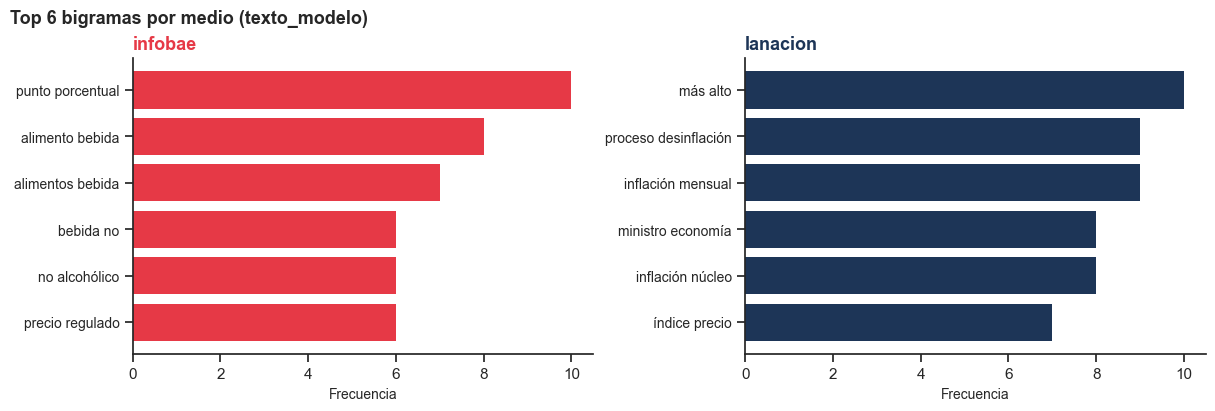

In [109]:
# Bigramas top 6 por grupo
vect_bg = CountVectorizer(ngram_range=(2, 2), min_df=1)
vect_bg.fit(df["texto_modelo"].tolist())  # fit global

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for ax, grupo in zip(axes, grupos):
    textos_grupo = df[df[COLUMNA_GRUPO] == grupo]["texto_modelo"].tolist()

    matriz  = vect_bg.transform(textos_grupo)
    scores  = matriz.sum(axis=0).A1
    vocab   = vect_bg.get_feature_names_out()

    top_idx  = scores.argsort()[-6:]
    bigramas = vocab[top_idx]
    valores  = scores[top_idx].astype(int)

    color = COLORES_GRUPO.get(grupo, "#888888")
    ax.barh(bigramas, valores, color=color, edgecolor="none")
    ax.set_title(grupo, fontsize=13, fontweight="bold", color=color, loc="left")
    ax.set_xlabel("Frecuencia", fontsize=10)
    ax.tick_params(axis="y", labelsize=10)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Top 6 bigramas por medio (texto_modelo)", fontsize=13, fontweight="bold", x=0, ha="left")
plt.show()

In [110]:
# Bag of Words cuenta volumen.
usar_minusculas_bow = False

# 'min_df=1' conserva terminos que aparecen al menos en 1 documento.
min_df_bow = 1

# 'max_df=0.95' descarta terminos que aparecen en mas del 95% de los documentos.
# Sirve para quitar palabras demasiado comunes y poco distintivas.
max_df_bow = 0.95

vectorizador_bow = CountVectorizer(
    lowercase=usar_minusculas_bow,
    min_df=min_df_bow,
    max_df=max_df_bow,
)

# 'fit' aprende que terminos formaran parte del vocabulario.
vectorizador_bow.fit(df["texto_modelo"])

# 'transform' convierte los textos en conteos numericos.
matriz_bow = vectorizador_bow.transform(df["texto_modelo"])

vocabulario_bow = vectorizador_bow.get_feature_names_out()
tabla_bow_docs = matriz_a_dataframe(matriz_bow, vocabulario_bow, df["id"])

tabla_bow_con_grupo = tabla_bow_docs.copy()
tabla_bow_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'groupby' agrupa filas que comparten el mismo valor de grupo.
agrupado_bow = tabla_bow_con_grupo.groupby("grupo")

# 'mean' calcula el promedio por columna dentro de cada grupo.
tabla_bow_grupos = agrupado_bow.mean()

display(tabla_bow_grupos.head())

,BCRA,Caputo,FMI,INDEC,IPC,Milei,REM,abanico,abogado,abrazo,...,week,wti,yo,york,ypf,zona,ámbito,ético,últimamente,único
grupo,,,,,,,,,,,,,,,,,,,,,
infobae,0.500000,1.0,0.166667,1.500000,2.5,1.166667,0.833333,0.166667,0.000000,0.000000,...,0.000000,0.166667,0.000000,0.000000,0.166667,0.166667,0.000000,0.000000,0.000000,0.166667
lanacion,0.833333,3.5,0.500000,2.333333,4.5,1.666667,1.166667,0.000000,0.166667,0.166667,...,0.166667,0.000000,0.166667,0.166667,0.166667,0.000000,0.166667,0.166667,0.166667,0.166667


In [111]:
# TF-IDF no mide solo frecuencia. Mide que tan distintivo es un termino.
usar_minusculas_tfidf = False

# Igual que antes, 'min_df=1' conserva terminos presentes al menos en 1 documento.
min_df_tfidf = 1

# Igual que antes, 'max_df=0.95' descarta terminos demasiado comunes.
max_df_tfidf = 0.95

vectorizador_tfidf = TfidfVectorizer(
    lowercase=usar_minusculas_tfidf,
    min_df=min_df_tfidf,
    max_df=max_df_tfidf,
)

# 'fit' aprende el vocabulario y las ponderaciones necesarias.
vectorizador_tfidf.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese aprendizaje.
matriz_tfidf = vectorizador_tfidf.transform(df["texto_modelo"])

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf_docs = matriz_a_dataframe(matriz_tfidf, vocabulario_tfidf, df["id"])

tabla_tfidf_con_grupo = tabla_tfidf_docs.copy()
tabla_tfidf_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

agrupado_tfidf = tabla_tfidf_con_grupo.groupby("grupo")
tabla_tfidf_grupos = agrupado_tfidf.mean()

display(tabla_tfidf_grupos.head())

,BCRA,Caputo,FMI,INDEC,IPC,Milei,REM,abanico,abogado,abrazo,...,week,wti,yo,york,ypf,zona,ámbito,ético,últimamente,único
grupo,,,,,,,,,,,,,,,,,,,,,
infobae,0.018632,0.025979,0.006486,0.037320,0.052724,0.028869,0.024549,0.009526,0.000000,0.000000,...,0.000000,0.009526,0.000000,0.000000,0.011045,0.007757,0.000000,0.000000,0.000000,0.006977
lanacion,0.022218,0.084531,0.016718,0.046918,0.084339,0.037190,0.026913,0.000000,0.010159,0.007341,...,0.010159,0.000000,0.010159,0.010159,0.008786,0.000000,0.007341,0.010159,0.006981,0.006305


In [112]:
def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    filas = []

    # 'iterrows' recorre la tabla fila por fila.
    for grupo, serie in tabla_matriz.iterrows():
        serie_positivos = serie[serie > 0]

        # Ordenamos de mayor a menor para ver primero los terminos mas fuertes.
        serie_ordenada = serie_positivos.sort_values(ascending=False)

        # 'head(top_n)' conserva los primeros N terminos.
        top = serie_ordenada.head(top_n)

        for termino, valor in top.items():
            filas.append({
                "grupo": grupo,
                "termino": termino,
                nombre_valor: round(float(valor), 4),
            })

    return pd.DataFrame(filas)

top_bow = extraer_top_por_grupo(tabla_bow_grupos, top_n=TOP_N, nombre_valor="frecuencia_media")
top_tfidf = extraer_top_por_grupo(tabla_tfidf_grupos, top_n=TOP_N, nombre_valor="tfidf_medio")

print("Top por grupo segun Bag of Words")
display(top_bow)

print("Top por grupo segun TF-IDF")
display(top_tfidf)

Top por grupo segun Bag of Words


,grupo,termino,frecuencia_media
0,infobae,semana,5.0000
1,infobae,aumento,3.6667
2,infobae,año,3.6667
3,infobae,marzo,3.6667
4,infobae,mercado,3.3333
5,infobae,enero,3.3333
6,infobae,bebida,3.1667
7,infobae,febrero,2.8333
8,infobae,ciento,2.8333
9,infobae,punto,2.6667


Top por grupo segun TF-IDF


,grupo,termino,tfidf_medio
0,infobae,semana,0.1113
1,infobae,ciento,0.1022
2,infobae,marzo,0.0952
3,infobae,aumento,0.0910
4,infobae,enero,0.0840
5,infobae,año,0.0813
6,infobae,mercado,0.0773
7,infobae,bebida,0.0756
8,infobae,punto,0.0737
9,infobae,canasta,0.0650


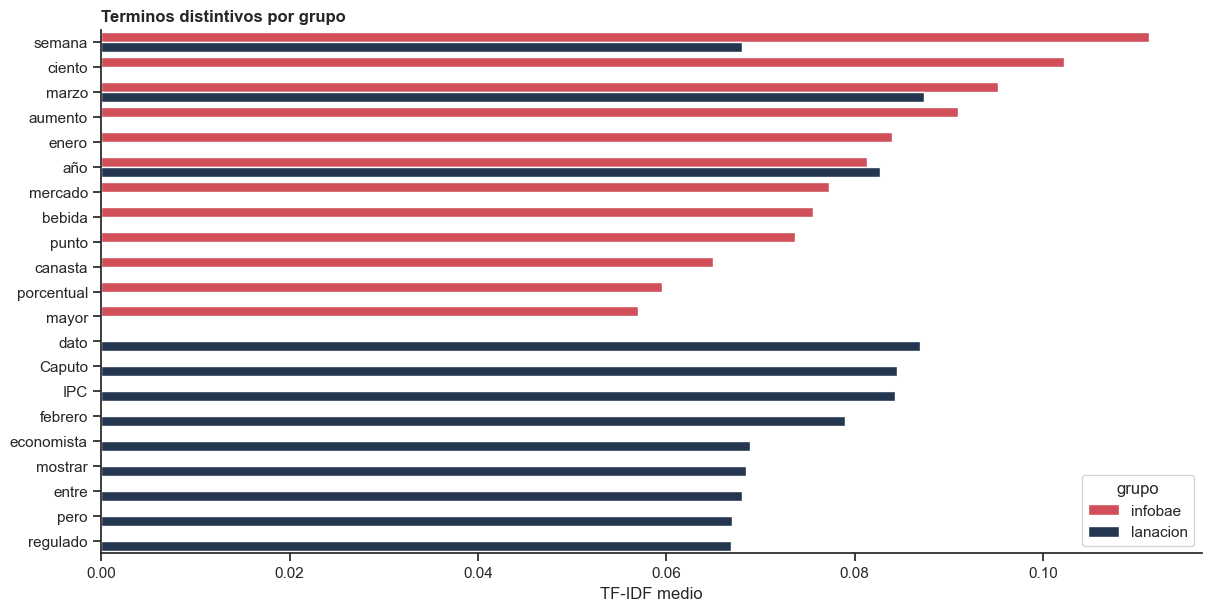

In [113]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

sns.barplot(
    data=top_tfidf,
    x="tfidf_medio",
    y="termino",
    hue="grupo",
    palette=COLORES_GRUPO,
    ax=ax,
)

ax.set_title("Terminos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("TF-IDF medio")
ax.set_ylabel("")

sns.despine(ax=ax)
plt.show()

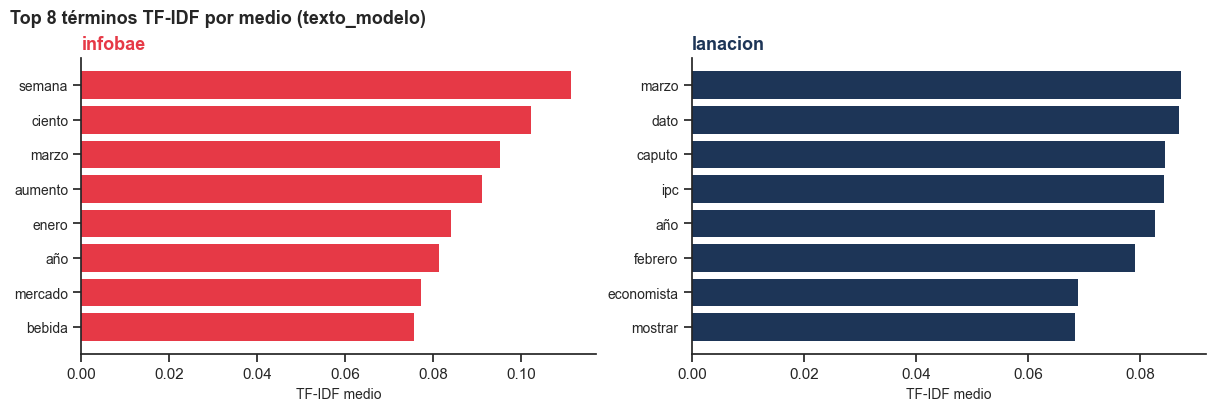

In [114]:
# TF-IDF top 8 por grupo
grupos = df[COLUMNA_GRUPO].unique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

vect_tfidf = TfidfVectorizer(min_df=1, max_df=0.95)
vect_tfidf.fit(df["texto_modelo"].tolist())  

for ax, grupo in zip(axes, grupos):
    textos_grupo = df[df[COLUMNA_GRUPO] == grupo]["texto_modelo"].tolist()

    matriz = vect_tfidf.transform(textos_grupo)
    scores = matriz.mean(axis=0).A1
    vocab  = vect_tfidf.get_feature_names_out()

    top_idx  = scores.argsort()[-8:]
    terminos = vocab[top_idx]
    valores  = scores[top_idx]

    color = COLORES_GRUPO.get(grupo, "#888888")
    ax.barh(terminos, valores, color=color, edgecolor="none")
    ax.set_title(grupo, fontsize=13, fontweight="bold", color=color, loc="left")
    ax.set_xlabel("TF-IDF medio", fontsize=10)
    ax.tick_params(axis="y", labelsize=10)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Top 8 términos TF-IDF por medio (texto_modelo)", fontsize=13, fontweight="bold", x=0, ha="left")
plt.show()

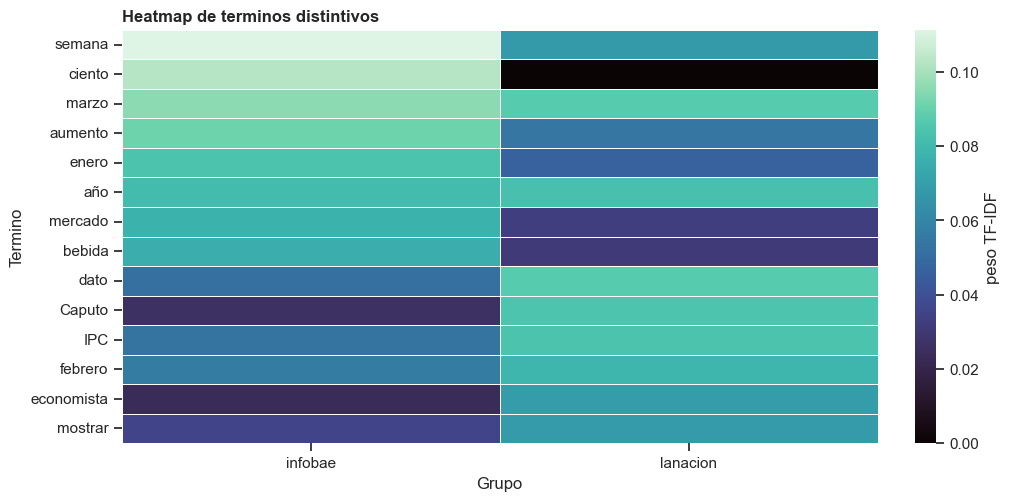

In [115]:
# Elegimos los primeros 8 terminos distintivos de cada grupo.
agrupado_top_tfidf = top_tfidf.groupby("grupo")
# 'head(8)' conserva los primeros 8 terminos de cada grupo.
top_ocho = agrupado_top_tfidf.head(8)
lista_terminos = top_ocho["termino"].tolist()

terminos_heatmap = []
for termino in lista_terminos:
    if termino not in terminos_heatmap:
        terminos_heatmap.append(termino)

# Volvemos a usar '.T' para que los terminos queden en el eje vertical.
matriz_heatmap = tabla_tfidf_grupos[terminos_heatmap].T

fig, ax = plt.subplots(figsize=(10, max(4, len(terminos_heatmap) * 0.35)), constrained_layout=True)

sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)

ax.set_title("Heatmap de terminos distintivos", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Termino")

plt.show()

Agreguen una celda Markdown nueva y comparen:

- que aparece como frecuente en ambos grupos;
- que aparece como distintivo en `TF-IDF`;
- que cambia entre volumen y especificidad.

### Comparacion entre Bag of Words, TF-IDF y bigramas

En **Bag of Words** aparecen los terminos mas repetidos. En Infobae se destacan `semana`, `año`, `aumento`, `marzo`, `mercado`, `enero`, `bebida` e `IPC`. En La Nacion aparecen con fuerza `dato`, `IPC`, `año`, `marzo`, `febrero`, `Caputo`, `economia`, `suba`, `economista` y `gobierno`.

En **TF-IDF** cambia un poco la lectura, porque no solo importa cuantas veces aparece una palabra, sino que tan distintiva es para cada grupo. Para Infobae quedaron arriba `semana`, `ciento`, `marzo`, `aumento`, `enero`. Para La Nacion se destacaron `marzo`, `dato`, `Caputo`, `IPC`, `febrero`.

Los **bigramas** ayudan a ver asociaciones de palabras. En Infobae aparecen expresiones como `punto porcentual`, `alimento bebida`, `precio regulado`, `banco central` e `inflacion nucleo`. En La Nacion aparecen `proceso desinflacion`, `inflacion mensual`, `ministro economia`, `indice precio`, `volver acelerar` y `precio relativo`.

La diferencia principal es que Bag of Words muestra volumen, TF-IDF muestra especificidad y los bigramas muestran combinaciones de sentido.


## 8. Del patron al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complica.

In [88]:
# Tomamos los 2 terminos mas distintivos de cada grupo.
agrupado_terminos = top_tfidf.groupby("grupo")
# 'head(2)' conserva los primeros 2 casos de cada grupo.
terminos_para_volver = agrupado_terminos.head(2)
# 'reset_index' recompone el indice para que la tabla quede limpia.
terminos_para_volver = terminos_para_volver.reset_index(drop=True)
display(terminos_para_volver)

,grupo,termino,tfidf_medio
0,infobae,semana,0.1113
1,infobae,ciento,0.1022
2,lanacion,marzo,0.0874
3,lanacion,dato,0.0870


In [89]:
def extraer_fragmentos(dataframe, grupo, termino, ventana=160, max_fragmentos=2):
    registros = []

    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto_original = getattr(fila, COLUMNA_TEXTO)
        doc = nlp_ajustado(texto_original)

        for token in doc:
            coincide_lema = lema_ajustado(token) == termino
            coincide_forma = token.text.lower() == termino

            if coincide_lema or coincide_forma:
                inicio = max(0, token.idx - ventana)
                fin = min(len(texto_original), token.idx + len(token.text) + ventana)

                fragmento = texto_original[inicio:fin].strip()

                if inicio > 0:
                    fragmento = "..." + fragmento

                if fin < len(texto_original):
                    fragmento = fragmento + "..."

                registros.append({
                    "grupo": grupo,
                    "termino": termino,
                    "titulo": fila.titulo,
                    "fragmento": fragmento,
                })

                break

        if len(registros) >= max_fragmentos:
            break

    return registros

In [90]:
registros_fragmentos = []

for fila in terminos_para_volver.itertuples(index=False):
    grupo = fila.grupo
    termino = fila.termino

    fragmentos_grupo = extraer_fragmentos(
        df,
        grupo,
        termino,
        ventana=VENTANA_FRAGMENTO,
        max_fragmentos=2,
    )

    registros_fragmentos.extend(fragmentos_grupo)

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)

,grupo,termino,titulo,fragmento
0,infobae,semana,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses","...5,7%, seguidos por el IPC núcleo (2,6%) y los precios Regulados (2,4%).\nEn efecto, el dato se difundió en medio de un debate sobre la metodología del In..."
1,infobae,semana,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses","...rtó con el 2,9 por ciento. \nEl dato de inflación en la Ciudad Autónoma de Buenos Aires, publicado por la Dirección General de Estadística y Censos porte..."
2,infobae,ciento,"La inflación de enero fue de 2,9% y acumuló 32,4% en los últimos doce meses","La inflación en enero de 2026 alcanzó 2,9%, según el Instituto Nacional de Estadística y Censos (Indec), lo que implicó una variación interanual de 32,4 por..."
3,infobae,ciento,"La inflación fue de 2,9% en febrero y acumuló 33,1% en los últimos doce meses","...y Censos (Indec), misma cifra que en enero. En los últimos doce meses, la suba acumulada fue de 33,1%, mientras que en el primer bimestre del año sumó 5,..."
4,lanacion,marzo,La inflación de febrero sería similar a la de enero y recién cedería en abril,"...pero impactan carne y regulados”, indicó el economista Lucio Garay Méndez.\nPor su parte, Fundación Capital prevé una inflación de 2,6% en febrero y de 2..."
5,lanacion,marzo,"La inflación de febrero fue 2,9%, por encima de lo esperado por el mercado","...lación atraviesa una pausa, con el índice estabilizado cerca del 3% mensual. En ese contexto, los ajustes en tarifas continúan presionando sobre el indic..."
6,lanacion,dato,"En medio de la polémica por la medición de la inflación, el IPC de enero marcó un 2,9%","...en la Ciudad. Los capítulos que mayores aumentos tuvieron fueron Alimentos y bebidas (4,7%) y Restaurantes y Hoteles (4,1%). La ropa tuvo deflación (-0,5..."
7,lanacion,dato,La inflación de febrero sería similar a la de enero y recién cedería en abril,"...el resultado es consistente con nuestra proyección para el nivel general”, explicó Florencia Iragui, economista de la firma.\nEn el caso de esta consulto..."


Agreguen una celda Markdown nueva y expliquen:

- como aparece en contexto al menos un termino distintivo de cada grupo;
- que cambia cuando vuelven al fragmento;
- que no habrian visto si se quedaban solo con las tablas.

### Vuelta a fragmentos del corpus

Al volver a los fragmentos, los terminos distintivos se entienden mejor. En Infobae, `semana` y `ciento` aparecen ligados a datos concretos de inflacion, variaciones mensuales, comparaciones interanuales y explicaciones sobre aumentos en rubros como alimentos o bebidas. Es decir, no son solo palabras frecuentes: forman parte de una narracion apoyada en cifras y mediciones.

En La Nacion, `marzo` y `dato` aparecen vinculados con expectativas, proyecciones de consultoras, mediciones del IPC y discusiones sobre si la inflacion se estabiliza, baja o vuelve a acelerarse. Ahi el foco parece estar mas puesto en la lectura economica del indicador y en lo que anticipa para los meses siguientes.

Esta lectura cercana sirve para no exagerar lo que dicen las tablas. Una palabra puede parecer muy importante por frecuencia, pero el fragmento muestra si realmente aporta al argumento o si aparece por cuestiones de estilo, fecha o contexto.


## 9. Cierre metodologico

Agreguen una celda Markdown nueva y respondan, de forma breve:

1. Que hallazgo creen que si pueden defender con evidencia.
2. Que habria salido mal si confiaban ciegamente en la primera salida de la maquina.
3. Que no se puede afirmar solo con estas representaciones.

El hallazgo que si podemos defender con evidencia es que ambos medios hablan de inflacion con un vocabulario comun, pero no exactamente con el mismo foco. Infobae muestra mas peso de terminos asociados a variaciones, porcentajes, semanas, aumentos y rubros de precios. La Nacion muestra mas presencia de palabras como `dato`, `Caputo`, `economista`, `gobierno`, `proceso` y expresiones como `proceso desinflacion` o `inflacion mensual`.

Si hubieramos confiado ciegamente en la primera salida de la maquina, habriamos aceptado como buena una categoria `MISC` demasiado grande y poco clara. Eso habria mezclado organismos, lugares, personas, indices y frases comunes. La revision humana permitio corregir parte de ese ruido y hacer mas defendible el analisis.

Lo que no se puede afirmar solo con estas representaciones es que un medio sea mas verdadero, mas objetivo o mas sesgado que el otro. Tampoco podemos generalizar sobre toda la linea editorial de Infobae o La Nacion, porque trabajamos con solo 12 textos. Lo que si podemos decir es que, en este corpus puntual, aparecen diferencias de vocabulario y de enfasis.


## Rubrica

| Criterio | Peso |
|---|---:|
| Construccion y justificacion del corpus | 30% |
| Inspeccion y ajuste del pipeline con spaCy | 25% |
| Comparacion de stopwords y decisiones de preprocesamiento | 15% |
| Analisis comparativo con evidencia | 20% |
| Claridad, limites del metodo y reproducibilidad | 10% |

## Checklist final

- El corpus tiene 12 textos y 6 por grupo.
- La columna `grupo_comparacion` esta completa.
- Respondieron las preguntas metodologicas.
- Compararon stopwords de `spaCy` y `NLTK`.
- Hicieron al menos dos ajustes humanos del pipeline.
- Compararon `Bag of Words`, `TF-IDF` y bigramas.
- Incluyeron al menos dos visualizaciones analiticas legibles.
- Volvieron a fragmentos concretos del corpus.
- Cerraron con una conclusion interpretativa y metodologica.
- El notebook corre de principio a fin.